## Task 1

**Choice of dataset**: [Kaggle: Brain Tumor MRI Dataset](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)

The dataset contains **7,200 human brain MRI images** categorized into four distinct classes:

* **Glioma**
* **Meningioma**
* **Pituitary tumor**
* **No tumor**

The dataset is structured into training and testing sets with balanced class distributions to ensure model reliability.

### Dataset Structure

| Category | Training Set (5,600 images) | Testing Set (1,600 images) |
| :--- | :--- | :--- |
| **Glioma** | 1,400 | 400 |
| **Meningioma** | 1,400 | 400 |
| **Pituitary** | 1,400 | 400 |
| **No Tumor** | 1,400 | 400 |

#### Directory Hierarchy
```text
Brain_Tumor_MRI/
├── Training/
│   ├── glioma/
│   ├── meningioma/
│   ├── pituitary/
│   └── notumor/
└── Testing/
    ├── glioma/
    ├── meningioma/
    ├── pituitary/
    └── notumor/
```

In [34]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import ImageOps
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
import torchvision.models as models


#### Part 1

In [2]:
train_dir = 'Brain_Tumor_MRI/Training/'
test_dir = 'Brain_Tumor_MRI/Testing/'
classes = ["glioma", "meningioma", "notumor", "pituitary"]

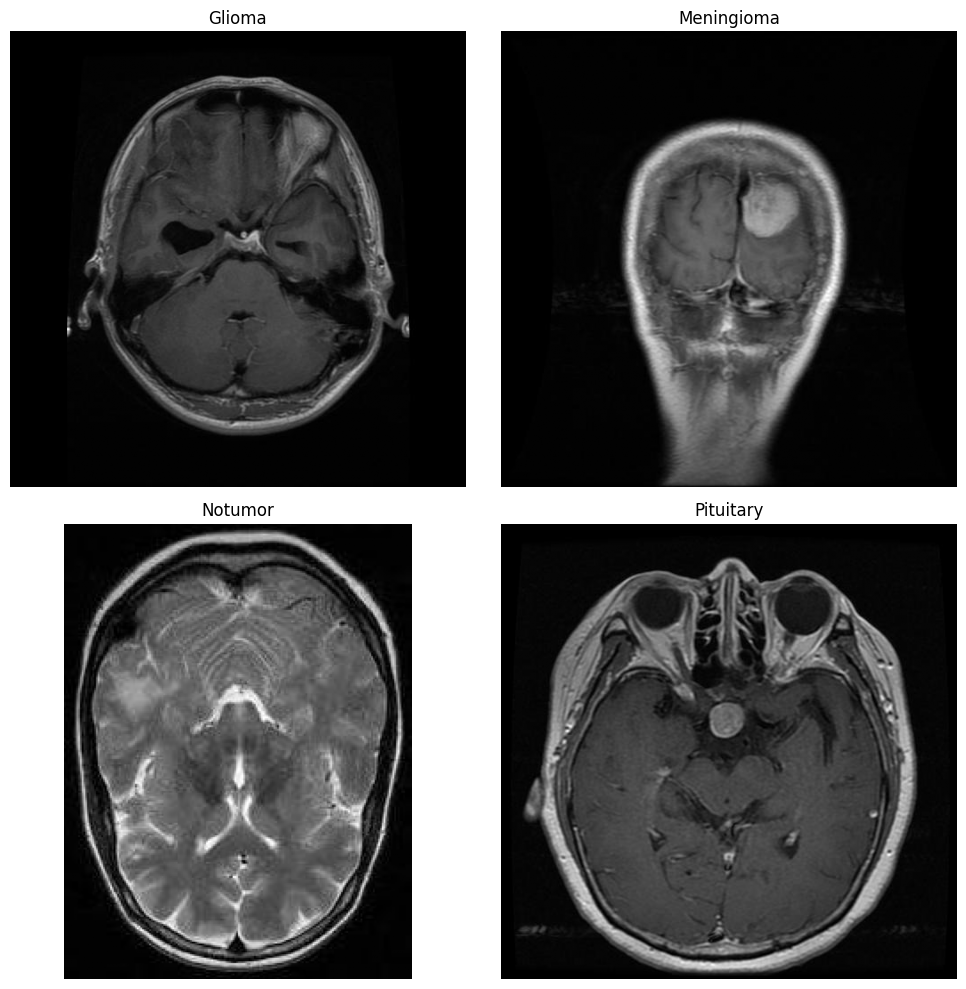

In [3]:
# Vizualize the 4 different types of Brain Tumor
plt.figure(figsize=(10, 10))
for i, label in enumerate(classes):
    label_path = os.path.join(train_dir, label)    
    first_image_name = os.listdir(label_path)[0]
    img_path = os.path.join(label_path, first_image_name)
    # MRIs look best in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    ax = plt.subplot(2, 2, i + 1)
    ax.imshow(img, cmap='gray') 
    ax.set_title(label.capitalize())
    ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Set to store unique image sizes
unique_sizes = set()
total_images = 0

for label in classes:
    label_path = os.path.join(train_dir, label)
    for img_name in os.listdir(label_path):
        img_path = os.path.join(label_path, img_name)
        img = cv2.imread(img_path)
        unique_sizes.add(img.shape[:2]) # (height, width)
        total_images += 1

In [5]:
print(f"Total training images: {total_images}")

if len(unique_sizes) > 1:
    print("The image sizes are NOT uniform")
else:
    print(f"All images are the exact same size: {list(unique_sizes)[0]}")

Total training images: 5600
The image sizes are NOT uniform


In [3]:
DEVICE = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
print(f"Device used: {DEVICE}")

Device used: cuda:2


In [4]:
# Hyperparameters
BATCH_SIZE = 32
HIDDEN_NEURONS = 512
LEARNING_RATE = 1e-4
EPOCHS = 10

In [5]:
# We will resize all the images to be of the size 224 x 224 (industry standard)
# To avoid distortions, we will pad the image to a square first, and then resize it. 
# (This adds black borders to the shorter sides so the aspect ratio is perfectly preserved)

class SquarePad:
    def __call__(self, image):
        # image.size returns (width, height) for PIL Images
        w, h = image.size
        max_dim = max(w, h)
        
        # Calculate padding for left, top, right, bottom
        horizontal_padding = int((max_dim - w) / 2)
        vertical_padding = int((max_dim - h) / 2)
        padding = (horizontal_padding, vertical_padding, max_dim - w - horizontal_padding, max_dim - h - vertical_padding)
        
        # Apply the pad (0 represents black pixels)
        return ImageOps.expand(image, border=padding, fill=0)

In [6]:
# Data Transforms Pipeline
data_transforms = transforms.Compose([
    SquarePad(),                           # Step 1: Make it a perfect square without distortion
    transforms.Resize((224, 224)),         # Step 2: Now safely resize the square to 224x224
    transforms.ToTensor(),                 # Step 3: Convert to PyTorch Tensor
    transforms.Normalize(                  # Step 4: Normalize the pixel values to have a mean of 0 and std of 1 (helps CNNs learn faster)
        mean=[0.485, 0.456, 0.406],        # these are the industry standard values for each channel
        std=[0.229, 0.224, 0.225]
    ) 
])

In [7]:
# datasets.ImageFolder looks at your subfolders and sorts them alphabetically
# which means the classes will be:
# 'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3
train_dataset = datasets.ImageFolder(root=train_dir, transform=data_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=data_transforms)

In [8]:
# Split train/val
total_train_size = len(train_dataset)
val_size = int(0.10 * total_train_size)
train_size = total_train_size - val_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])
total_size = train_size + val_size + len(test_dataset)

In [12]:
print(f"Train size: {train_size} ({train_size / total_size:.2%})")
print(f"Val size:   {val_size} ({val_size / total_size:.2%})")
print(f"Test size:  {len(test_dataset)} ({len(test_dataset) / total_size:.2%})")

Train size: 5040 (70.00%)
Val size:   560 (7.78%)
Test size:  1600 (22.22%)


In [9]:
# Create loaders
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [14]:

# VERIFY the shape of a single batch and the class mapping
images, labels = next(iter(train_loader))
print(f"Batch Image Shape: {images.shape}") # Should be [32, 3, 224, 224]
print(f"Batch Label Shape: {labels.shape}") # Should be [32]
print(f"Class mapping: {train_dataset.class_to_idx}")

Batch Image Shape: torch.Size([32, 3, 224, 224])
Batch Label Shape: torch.Size([32])
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [10]:
# reverse mapping for later to look up the actual class name using the label index
idx_to_class = {
    0: 'glioma',
    1: 'meningioma',
    2: 'notumor',
    3: 'pituitary'
}

In [12]:
def imshow_unnormalized(img):
    # PyTorch tensors are ordered (Channels, Height, Width) -> (3, 224, 224)
    # Matplotlib expects (Height, Width, Channels) -> (224, 224, 3)
    img = img.numpy().transpose((1, 2, 0)) 
    
    # Reverse the normalization math: image = (image * std) + mean
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean 

    # Clip values to ensure they are strictly between 0 and 1
    img = np.clip(img, 0, 1) 
    plt.imshow(img)

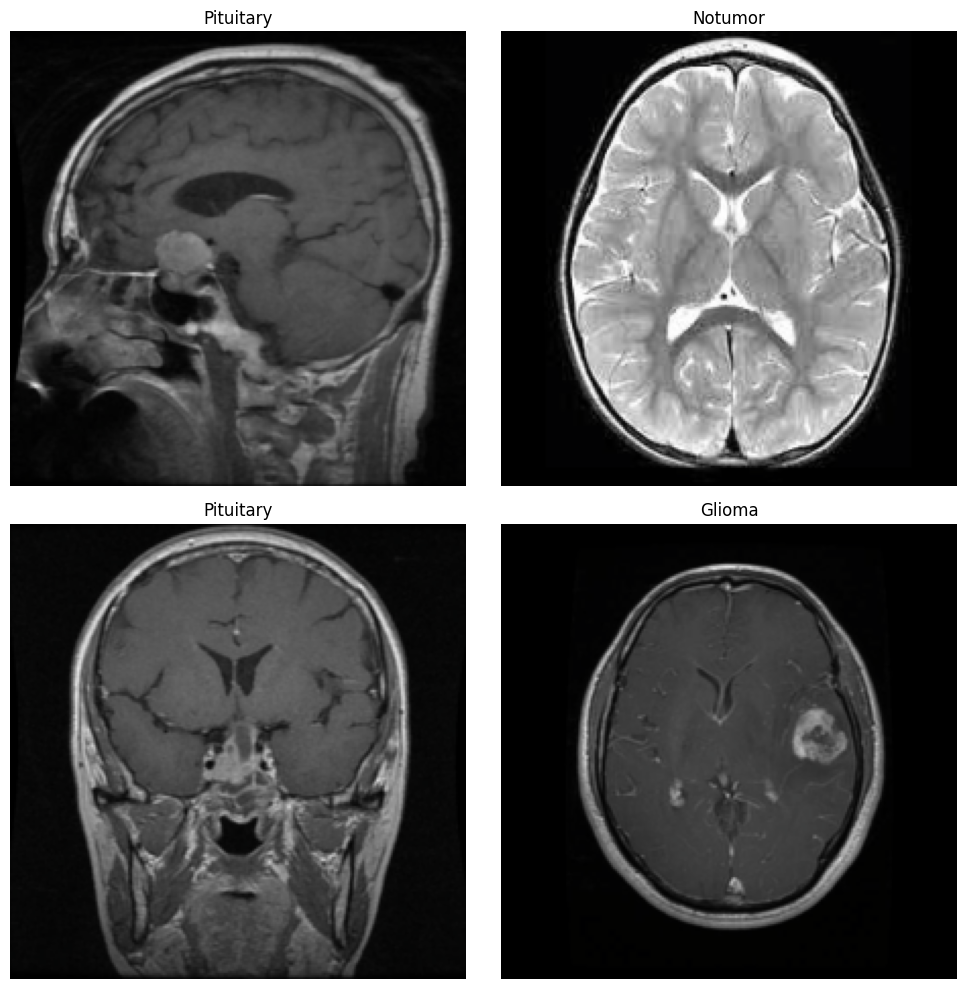

In [15]:
# VERIFY that the loaded images are not distorted
images_check = images[:4]
labels_check = labels[:4]

plt.figure(figsize=(10, 10))
for i in range(4):
    ax = plt.subplot(2, 2, i + 1)
    imshow_unnormalized(images[i])
    class_name = idx_to_class[labels[i].item()]
    ax.set_title(class_name.capitalize())
    ax.axis('off')

plt.tight_layout()
plt.show()

In [28]:
class BrainTumorCNN(nn.Module):
    def __init__(self, hidden_neurons, num_classes=4):
        super(BrainTumorCNN, self).__init__()
        
        # PHASE 1: FEATURE LEARNING
        # Input assumes an RGB image resized to 224 x 224 x 3
        
        # Layer 1: Apply 16 filters, creating 16 feature maps.
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        # Layer 2: Takes the 16 feature maps from before, applies 32 filters.
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        # Layer 3: Takes 32 feature maps, applies 64 filters. 
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        # We define a 2x2 Max pooling window that slides over the image.
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # After Pool 1: Cut size in half to 112 x 112
        # After Pool 2: Cut size in half to 56 x 56
        # After Pool 3: Cut size in half to 28 x 28

        # PHASE 2: CLASSIFICATION

        # Flattened size: 64 channels * 28 height * 28 width
        flattened_size = 64 * 28 * 28
        
        # 1 hidden layer
        self.fc1 = nn.Linear(in_features=flattened_size, out_features=hidden_neurons)
        
        # Add Dropout to prevent overfitting
        self.dropout = nn.Dropout(p=0.5)
        
        # Final classification layer
        self.fc2 = nn.Linear(in_features=hidden_neurons, out_features=num_classes)

    def forward(self, x):
        # Convolution -> ReLU -> Max Pooling
        # Convolution blocks (224 -> 112 -> 56 -> 28)
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        # Flatten the tensor
        x = torch.flatten(x, 1)
        
        # Fully connected layers with dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

In [29]:
def train_model(model, optimizer, best_model_path, train_loader):
    # TRAINING PHASE
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    print("Training Phase")

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        correct = 0
        total_images = 0
        
        for X_t, y_t in train_loader:
            X_t, y_t = X_t.to(DEVICE), y_t.to(DEVICE)
            # Clear old gradients
            optimizer.zero_grad()
            # Forward pass
            outputs = model(X_t)
            # Calculate loss
            loss = criterion(outputs, y_t)
            # Backward pass
            loss.backward()
            # Update weights
            optimizer.step()
            
            running_loss += loss.item() * X_t.size(0) # for the batch
            _, predicted = torch.max(outputs, dim=1)
            total_images += y_t.size(0) 
            correct += (predicted == y_t).sum().item()
            
        epoch_train_loss = running_loss / total_images
        epoch_train_acc = correct / total_images
        
        # VALIDATION PHASE
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total_images = 0
        
        with torch.no_grad():
            for X_v, y_v in valid_loader:
                X_v, y_v = X_v.to(DEVICE), y_v.to(DEVICE)
                outputs = model(X_v)
                loss = criterion(outputs, y_v)
                
                val_running_loss += loss.item() * X_v.size(0)
                _, predicted = torch.max(outputs, dim=1)
                val_total_images += y_v.size(0)
                val_correct += (predicted == y_v).sum().item()
                
        epoch_val_loss = val_running_loss / val_total_images
        epoch_val_acc = val_correct / val_total_images
        
        # Save history for plots
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

        # Check for new best model ---
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), best_model_path)
            print("Found new best model at Epoch", epoch+1) 
            print(f"    Validation Accuracy: {epoch_val_acc:.4f}")
    return history

In [17]:
def plot_history(history, title):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=16)
    # Plot 1: Training and Validation Loss
    axs[0].plot(range(1, EPOCHS+1), history['train_loss'], label='Train Loss')
    axs[0].plot(range(1, EPOCHS+1), history['val_loss'], label='Validation Loss')
    axs[0].set_title('Loss vs. Epochs')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)
    # Plot 2: Training and Validation Accuracy
    axs[1].plot(range(1, EPOCHS+1), history['train_acc'], label='Train Accuracy')
    axs[1].plot(range(1, EPOCHS+1), history['val_acc'], label='Validation Accuracy')
    axs[1].set_title('Accuracy vs. Epochs')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [18]:
def test_model(model, best_model_path):
    # Load the best weights into the model
    model.load_state_dict(torch.load(best_model_path))
    model.eval()

    y_preds = []
    y_true = []

    # TESTING PHASE
    with torch.no_grad():
        for X_t, y_t in test_loader:
            X_t = X_t.to(DEVICE)
            outputs = model(X_t)
            _, predicted = torch.max(outputs, dim=1) 
            y_preds.extend(predicted.cpu().numpy())
            y_true.extend(y_t.cpu().numpy())

    return y_preds, y_true

In [19]:
def draw_confusion_matrix(y_true, y_preds, title):
    cm = confusion_matrix(y_true, y_preds)
    plt.figure(figsize=(7, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

In [19]:
model_cnn = BrainTumorCNN(hidden_neurons = HIDDEN_NEURONS,num_classes=4).to(DEVICE)
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=LEARNING_RATE)
best_cnn_model_path = "best_cnn_brain_tumor_model.pth"

In [ ]:
cnn_training_history = train_model(model_cnn, optimizer_cnn, best_cnn_model_path, train_loader=train_loader)


Training Phase
Epoch 1 | Train Loss: 0.7926 | Val Loss: 0.5182
Found new best model at Epoch 1
    Validation Accuracy: 0.8125
Epoch 2 | Train Loss: 0.5154 | Val Loss: 0.4285
Found new best model at Epoch 2
    Validation Accuracy: 0.8339
Epoch 3 | Train Loss: 0.4193 | Val Loss: 0.3633
Found new best model at Epoch 3
    Validation Accuracy: 0.8661
Epoch 4 | Train Loss: 0.3511 | Val Loss: 0.3126
Found new best model at Epoch 4
    Validation Accuracy: 0.8732
Epoch 5 | Train Loss: 0.2931 | Val Loss: 0.2977
Found new best model at Epoch 5
    Validation Accuracy: 0.8839
Epoch 6 | Train Loss: 0.2559 | Val Loss: 0.2800
Found new best model at Epoch 6
    Validation Accuracy: 0.8911
Epoch 7 | Train Loss: 0.2141 | Val Loss: 0.2429
Found new best model at Epoch 7
    Validation Accuracy: 0.9143
Epoch 8 | Train Loss: 0.1889 | Val Loss: 0.2263
Epoch 9 | Train Loss: 0.1526 | Val Loss: 0.2063
Found new best model at Epoch 9
    Validation Accuracy: 0.9214
Epoch 10 | Train Loss: 0.1375 | Val Loss:

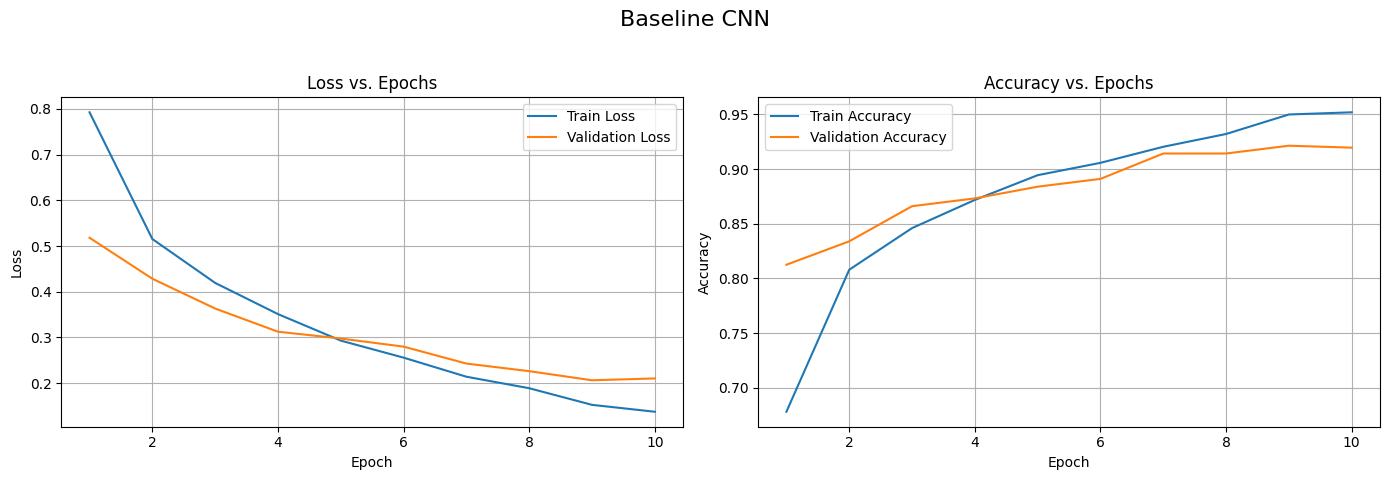

In [21]:
plot_history(cnn_training_history, title="Baseline CNN")

In [22]:
y_preds_cnn, y_true_cnn = test_model(model_cnn, best_cnn_model_path)

In [23]:

print(classification_report(y_true_cnn, y_preds_cnn, target_names=classes))

              precision    recall  f1-score   support

      glioma       0.87      0.67      0.76       400
  meningioma       0.77      0.89      0.82       400
     notumor       0.88      0.97      0.92       400
   pituitary       0.96      0.93      0.95       400

    accuracy                           0.86      1600
   macro avg       0.87      0.86      0.86      1600
weighted avg       0.87      0.86      0.86      1600



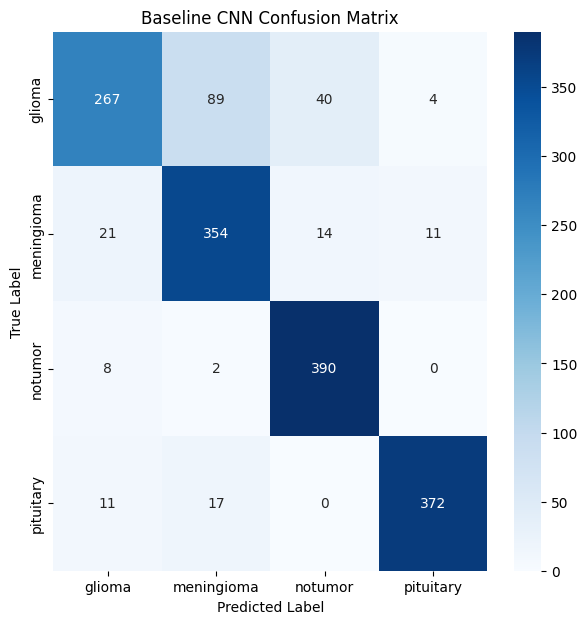

In [24]:
draw_confusion_matrix(y_true_cnn, y_preds_cnn, title="Baseline CNN Confusion Matrix")

##### Baseline CNN Report

**Data Preprocessing**:

Images were pre-processed using a SquarePad strategy. This added black borders to preserve the original aspect ratio of the MRI scans before resizing to the industry standard **$224 \times 224 \times 3$**. Normalization was applied to the pixels using industry standard mean and standard deviation.


**Architecture Design**:

* Pattern Choice: A 3-layer stack of **Conv + ReLU + MaxPooling**. They provide enough depth to move from single edge detection (layer 1) to complex texture extraction by layer 3. Max pooling was used after every conolution to reduce the spatial dimentions ($224 \rightarrow 112 \rightarrow 56 \rightarrow 28$).

* Classification: A hidden dense layer (512 neurons) was used to learn non-linear combinations of the **$50,176$** flattened features.

* Regularization: A Dropout (0.5) layer was placed before the final output to mitigate the risk of overfitting.

**Training**:

The model was trained for 10 epochs using the Adam optimizer and Cross-Entropy Loss.

**Analysis of Metrics & Curves**:

* **Confusion**: The model struggles most with **Glioma**, misclassifying **$89$** instances as **Meningioma**. This is likely due to the visual similarities between these two tumor types.

* **Detection Strength:** The model is very good at identifying healthy brains (**No Tumor**), with only **10** false negative in the test set.

#### Part 2

In [14]:
# Load the pre-trained ResNet50 model, trained on 1.2 million ImageNet images
resnet_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

In [15]:
# Freeze the core convolutional base
# We don't want to update these weights; they already know how to detect edges and textures.
for param in resnet_model.parameters():
    param.requires_grad = False

In [16]:
# We replace the final classification head with a new untrained head specifically for our 4 classes
# that way the only training we do is making the final layer translate the visual observations into the 4 specific medical labels.
num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Sequential(
    nn.Linear(num_features, HIDDEN_NEURONS),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(HIDDEN_NEURONS, 4)
)

In [ ]:
resnet_model = resnet_model.to(DEVICE)
optimizer_resnet = optim.Adam(resnet_model.fc.parameters(), lr=LEARNING_RATE)
best_resnet_model_path = "best_resnet_brain_tumor_model.pth"

In [ ]:
resnet_history = train_model(resnet_model, optimizer_resnet, best_resnet_model_path, train_loader=train_loader)

Training Phase
Epoch 1 | Train Loss: 0.9030 | Val Loss: 0.5759
Found new best model at Epoch 1
    Validation Accuracy: 0.8518
Epoch 2 | Train Loss: 0.4857 | Val Loss: 0.4172
Found new best model at Epoch 2
    Validation Accuracy: 0.8750
Epoch 3 | Train Loss: 0.3782 | Val Loss: 0.3908
Epoch 4 | Train Loss: 0.3317 | Val Loss: 0.3442
Found new best model at Epoch 4
    Validation Accuracy: 0.8804
Epoch 5 | Train Loss: 0.2991 | Val Loss: 0.3065
Found new best model at Epoch 5
    Validation Accuracy: 0.9018
Epoch 6 | Train Loss: 0.2689 | Val Loss: 0.2843
Epoch 7 | Train Loss: 0.2404 | Val Loss: 0.2745
Found new best model at Epoch 7
    Validation Accuracy: 0.9054
Epoch 8 | Train Loss: 0.2311 | Val Loss: 0.2733
Found new best model at Epoch 8
    Validation Accuracy: 0.9071
Epoch 9 | Train Loss: 0.2158 | Val Loss: 0.2457
Found new best model at Epoch 9
    Validation Accuracy: 0.9089
Epoch 10 | Train Loss: 0.2034 | Val Loss: 0.2675


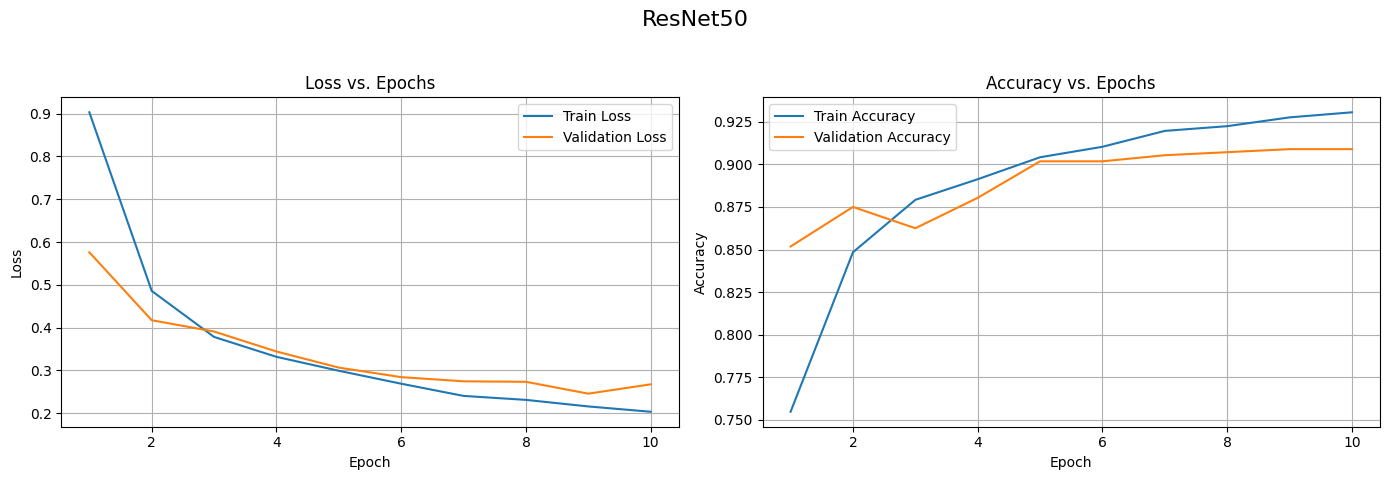

In [19]:
plot_history(resnet_history, title="ResNet50")

In [20]:
y_preds_resnet, y_true_resnet = test_model(resnet_model, best_resnet_model_path)

In [21]:

print(classification_report(y_true_resnet, y_preds_resnet, target_names=classes))

              precision    recall  f1-score   support

      glioma       0.95      0.70      0.80       400
  meningioma       0.77      0.84      0.80       400
     notumor       0.89      0.99      0.94       400
   pituitary       0.91      0.96      0.93       400

    accuracy                           0.87      1600
   macro avg       0.88      0.87      0.87      1600
weighted avg       0.88      0.87      0.87      1600



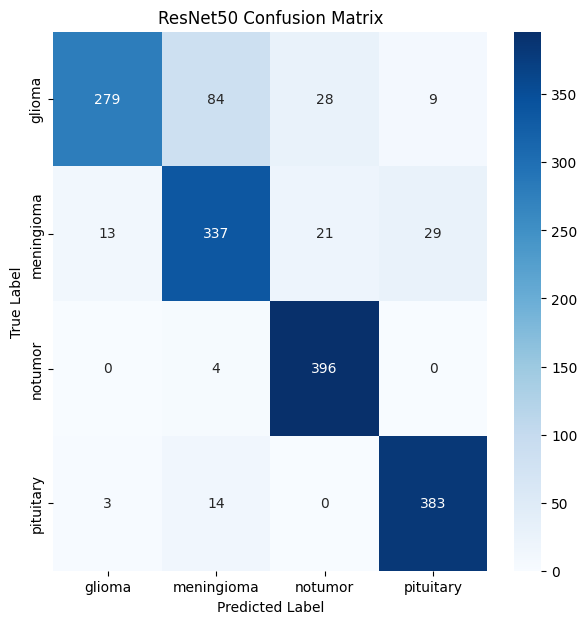

In [22]:
draw_confusion_matrix(y_true_resnet, y_preds_resnet, title="ResNet50 Confusion Matrix")

Both the Baseline CNN and ResNet50 achieved nearly identical performance.

The lack of a significant difference happens because the 4-class MRI dataset relies on highly specific grayscale textures. The custom CNN possesses sufficient architectural capacity to map these specific domain features from scratch. ResNet50 weights are optimized for everyday color photography.

This goes to show the importance of knowing the target domain (in our case medical imaging), which differs from the source domain of ResNet50 (ImageNet).

#### Part 3

In [25]:
# Training Pipeline (with Data Augmentation)
data_augmented_pipeline = transforms.Compose([
    SquarePad(),
    transforms.Resize((224, 224)),
    # Data Augmentation specific to MRIs:
    transforms.RandomHorizontalFlip(p=0.5), # 50% chance to mirror the brain left/right
    transforms.RandomRotation(degrees=15),  # Randomly tilt between -15 and +15 degrees
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
train_dataset_aug = datasets.ImageFolder(root=train_dir, transform=data_augmented_pipeline)
train_subset_aug = Subset(train_dataset_aug, train_subset.indices)
train_augmented_loader = DataLoader(train_subset_aug, batch_size=BATCH_SIZE, shuffle=True)

In [30]:
model_augmented_cnn = BrainTumorCNN(hidden_neurons = HIDDEN_NEURONS, num_classes=4).to(DEVICE)
optimizer_augmented_cnn = optim.Adam(model_augmented_cnn.parameters(), lr=LEARNING_RATE)
best_cnn_model_augmented_path = "best_cnn_brain_tumor_model_augmented.pth"

In [31]:
cnn_augmented_training_history = train_model(model_augmented_cnn, optimizer_augmented_cnn, best_cnn_model_augmented_path, train_loader=train_augmented_loader)

Training Phase
Epoch 1 | Train Loss: 0.7880 | Val Loss: 0.5958
Found new best model at Epoch 1
    Validation Accuracy: 0.7714
Epoch 2 | Train Loss: 0.5686 | Val Loss: 0.4900
Found new best model at Epoch 2
    Validation Accuracy: 0.8161
Epoch 3 | Train Loss: 0.4804 | Val Loss: 0.4405
Found new best model at Epoch 3
    Validation Accuracy: 0.8357
Epoch 4 | Train Loss: 0.4318 | Val Loss: 0.4039
Found new best model at Epoch 4
    Validation Accuracy: 0.8589
Epoch 5 | Train Loss: 0.3866 | Val Loss: 0.3556
Found new best model at Epoch 5
    Validation Accuracy: 0.8696
Epoch 6 | Train Loss: 0.3590 | Val Loss: 0.3382
Found new best model at Epoch 6
    Validation Accuracy: 0.8768
Epoch 7 | Train Loss: 0.3269 | Val Loss: 0.3163
Epoch 8 | Train Loss: 0.2949 | Val Loss: 0.2887
Found new best model at Epoch 8
    Validation Accuracy: 0.9071
Epoch 9 | Train Loss: 0.2747 | Val Loss: 0.2633
Found new best model at Epoch 9
    Validation Accuracy: 0.9196
Epoch 10 | Train Loss: 0.2613 | Val Loss:

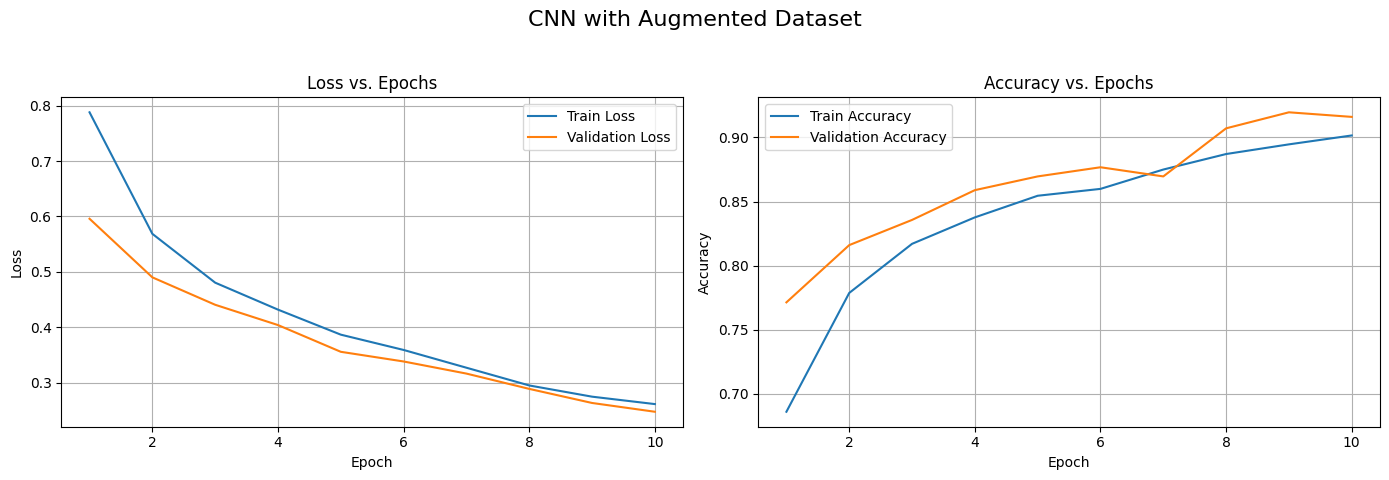

In [32]:
plot_history(cnn_augmented_training_history, title="CNN with Augmented Dataset")

In [35]:
y_preds_augmented_cnn, y_true_augmented_cnn = test_model(model_augmented_cnn, best_cnn_model_augmented_path)

In [36]:

print(classification_report(y_true_augmented_cnn, y_preds_augmented_cnn, target_names=classes))

              precision    recall  f1-score   support

      glioma       0.87      0.62      0.73       400
  meningioma       0.76      0.79      0.77       400
     notumor       0.79      0.99      0.87       400
   pituitary       0.96      0.95      0.96       400

    accuracy                           0.84      1600
   macro avg       0.84      0.84      0.83      1600
weighted avg       0.84      0.84      0.83      1600



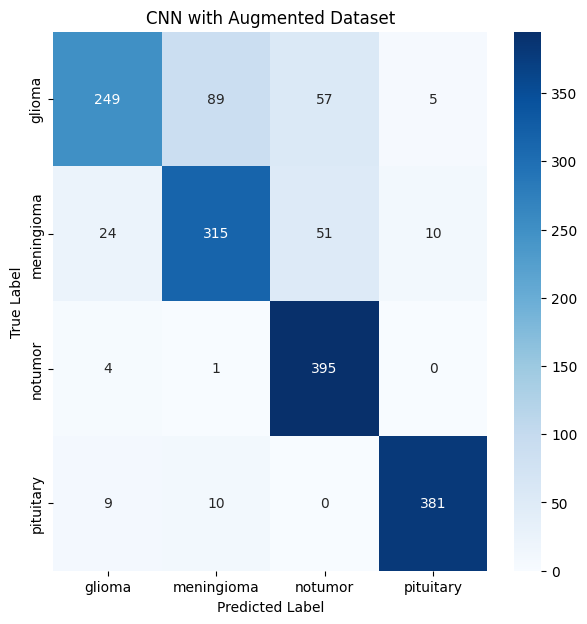

In [37]:
draw_confusion_matrix(y_true_augmented_cnn, y_preds_augmented_cnn, title="CNN with Augmented Dataset")


**Data Augmentation Analysis**

* **Methodology:** Applied random horizontal flipping ($p=0.5$) and random rotations ($\pm 15^\circ$) exclusively to the training set.

* **Results:** The augmented model performed slightly *worse* than the baseline, dropping from an F1-score of ~0.86 to ~0.84. The training curves also showed slower learning. Since the images changed every epoch, the learning task became harder.